# **SIMULATION**

### 1. Problem Setup

Let us discuss the mathematical setup of the problem in a fair amount of mathematical detail.

### 2. Simulation Data

We now visualise the simulation data provided by Mouad. Firstly, we important all required modules and load the data,

In [140]:
# Dependencies,
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation

# Loading the simulation data,
with h5py.File("cylinder_Re100.h5", "r") as file:
    t = file["t"][:]
    u = file["u"][:]
    v = file["v"][:]
    p = file["p"][:]
    x = file["x"][:]
    y = file["y"][:]

Inspecting the our time values `t`, we confirm that we have `201` time steps that range from `t=400` to `t=420`. Each step represents `0.1` units of time. Moreover, we have `82,872` number of nodes which take one a value of $u$, $v$ and $p$ at a given time $t$. Let us now visualise the velocity field for a given time $t$,

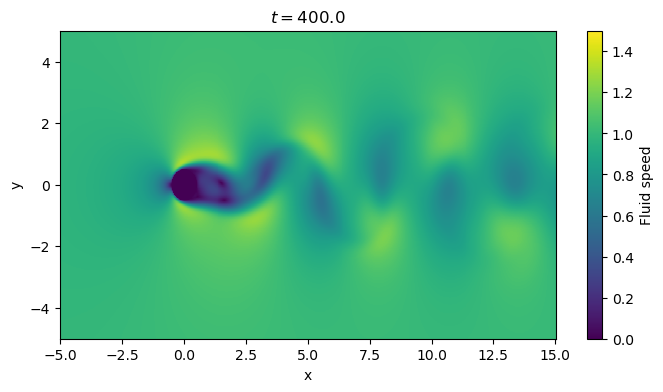

In [139]:
# Specifying time step,
time_idx = 0
u_snap, v_snap, p_snap, x_snap, y_snap, t_snap = u[time_idx], v[time_idx], p[time_idx], x[time_idx], y[time_idx], t[time_idx]

# Selecting region of interest,
padding = 0.25
x_min, x_max = -5, 15
y_min, y_max = -5, 5

# Applying boolean mask,
bool_mask = (x_snap >= x_min-padding) & (x_snap <= x_max+padding) & (y_snap >= y_min-padding) & (y_snap <= y_max+padding) 
u_snap, v_snap, p_snap, x_snap, y_snap = u_snap[bool_mask], v_snap[bool_mask], p_snap[bool_mask], x_snap[bool_mask], y_snap[bool_mask]

# Computing the speed (scalar field),
speed = np.sqrt(u_snap**2 + v_snap**2)

# Creating mesh grid,
nx, ny = 500, 500 # <-- grid resolution.
xi = np.linspace(start=x_min, stop=x_max, num=nx)
yi = np.linspace(start=y_min, stop=y_max, num=ny)
X_grid, Y_grid = np.meshgrid(xi, yi)

# Interpolation (creating speed and pressure grids),
speed_grid = griddata(
    points=np.column_stack([x_snap, y_snap]),
    values=speed,
    xi=(X_grid, Y_grid),
    method='cubic'
)

pressure_grid = griddata(
    points=np.column_stack([x_snap, y_snap]),
    values=p_snap,
    xi=(X_grid, Y_grid),
    method="cubic"
)

# Plotting,
plt.figure(figsize=(8, 4))
plt.pcolormesh(X_grid, Y_grid, speed_grid, shading='auto', cmap='viridis', vmin=0, vmax=1.5)
plt.colorbar(label='Fluid speed')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f"$t={t_snap}$")
plt.show()

Creating an animation,

# References


Numerical simulation data of a two-dimensional flow around a fixed circular cylinder. Boudina (2021). URL: https://zenodo.org/records/5039610?utm_source=chatgpt.com 
